In [4]:
import numpy as np
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec


In [5]:
glove2word2vec('datasets/test_glove.txt', 'datasets/test_wv.txt')

C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_12652\40271968.py:1: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec('datasets/test_glove.txt', 'datasets/test_wv.txt')


(8, 4)

In [6]:
# Loads the word vectors
model = KeyedVectors.load_word2vec_format('datasets/test wv.txt', binary=False)

In [7]:
model.similarity('king', 'queen')

np.float32(0.9998945)

In [8]:
model.similarity('mango', 'apple')

np.float32(0.99897045)

In [9]:
model.similarity('computer', 'woman')

np.float32(-0.61038744)

In [10]:
model.similarity('king', 'apple')

np.float32(0.4803489)

In [11]:
model.most_similar('keyboard', topn=1)

[('computer', 0.9996709227561951)]

In [12]:
model.most_similar(positive=['king','woman'], negative=['man'], topn=1)

[('queen', 0.9998007416725159)]

#### Visualization of Data

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [14]:
pca = PCA(n_components=2, random_state=0)

In [16]:
vectors_2d = pca.fit_transform(model.vectors)
vectors_2d

array([[-0.68762124, -0.35608202],
       [-0.7569957 , -0.3840752 ],
       [-0.39322007, -0.14959295],
       [-0.4625945 , -0.17758611],
       [-0.38705248,  0.6145134 ],
       [-0.3594681 ,  0.59929883],
       [ 1.4869586 , -0.07137666],
       [ 1.5599931 , -0.07509939]], dtype=float32)

In [17]:
model.index_to_key

['king', 'queen', 'man', 'woman', 'apple', 'mango', 'computer', 'keyboard']

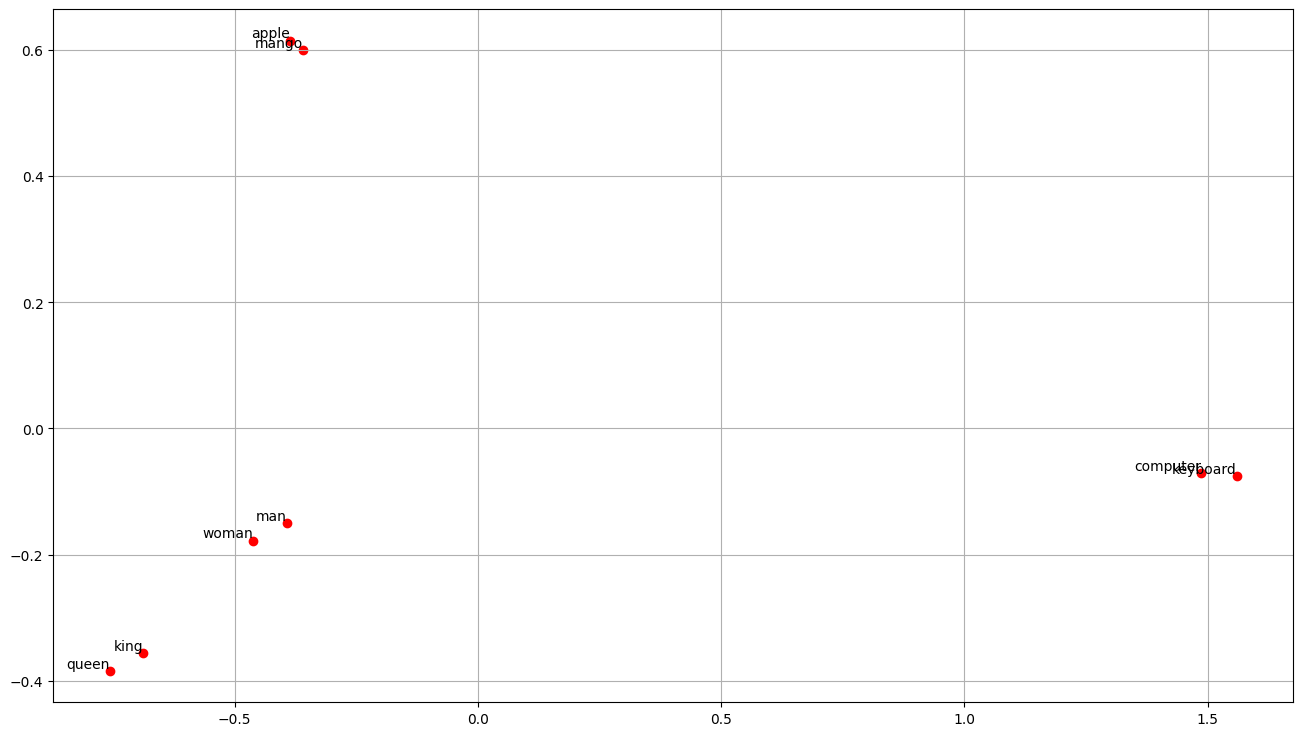

In [19]:
plt.figure(figsize = (16,9))
plt.grid()
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color = 'r')

for i, word in enumerate(model.index_to_key):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=10, ha='right', va='bottom')

plt.show()